### Monte Carlo Shapley Effects with Correlated Inputs

This notebook demonstrates the Monte Carlo approach for estimating Shapley effects when input variables may be correlated. The method is based on the formulation by Owen & Prieur [1], which uses conditional sampling to account for dependence structures that standard variance-based methods cannot handle.

The key idea is to estimate $v(u) = \text{Cov}[f(\mathbf{X}), f(\mathbf{X}_u)]$, where $\mathbf{X}_u$ shares the same background variables as $\mathbf{X}$ but conditions on the subset $u$. The Shapley effect for variable $i$ is then:

$$
\text{Sh}_i = \sum_{u \subseteq \{1,\dots,d\} \setminus \{i\}} \frac{|u|!\,(d - |u| - 1)!}{d!}\,[v(u \cup \{i\}) - v(u)]
$$

Three usage patterns are illustrated:
1. Using the **trained surrogate model** as the model function (independent inputs)
2. Using the **trained surrogate model** with a **correlation matrix**
3. Using a **user-defined function** with a custom distribution

Two computation methods are available:
- `'exhaustive'`: enumerates all $2^d - 1$ non-empty subsets (exact but costly for large $d$)
- `'permutation'`: uses random permutations with lazy caching (scalable)

---
[1] Owen, A. B., & Prieur, C. (2017). "On Shapley value for measuring importance of dependent inputs." *SIAM/ASA Journal on Uncertainty Quantification*, 5(1), 986–1004.

In [1]:
# Import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from shapleyx import rshdmr
from shapleyx.utilities.mc_shapley import (
    GaussianCopulaUniform,
    MultivariateNormal,
)

from importlib.metadata import version
print(f"Running on ShapleyX v{version('shapleyx')}")

Running on ShapleyX v0.2


##### Test function: Ishigami

The Ishigami function is a standard benchmark for sensitivity analysis with three inputs:

$$
f(\mathbf{x}) = \sin(x_1) + a \sin^2(x_2) + b x_3^4 \sin(x_1), \quad x_i \in [-\pi, \pi]
$$

We use $a=7$, $b=0.1$ and draw samples uniformly.

In [2]:
def ishigami(x1, x2, x3, a=7.0, b=0.1):
    """Ishigami function for vectorised evaluation."""
    return np.sin(x1) + a * np.sin(x2)**2 + b * x3**4 * np.sin(x1)


def ishigami_1d(x):
    """Ishigami function taking a 1D array (used with MC Shapley)."""
    return np.sin(x[0]) + 7.0 * np.sin(x[1])**2 + 0.1 * x[2]**4 * np.sin(x[0])


def get_column_labels(n):
    return [f'X{i+1}' for i in range(n)]

##### Generate training data and fit the surrogate model

We generate 256 samples and fit an RS-HDMR surrogate using ARD with cross-validation.

In [3]:
# Generate independent uniform samples
np.random.seed(42)
N = 256
d = 3

X1 = np.random.uniform(-np.pi, np.pi, N)
X2 = np.random.uniform(-np.pi, np.pi, N)
X3 = np.random.uniform(-np.pi, np.pi, N)
Y = ishigami(X1, X2, X3)

dataframe = pd.DataFrame({
    'X1': X1, 'X2': X2, 'X3': X3, 'Y': Y
})
print(f'{len(dataframe)} samples generated')

256 samples generated


Found a DataFrame

Transforming data to unit hypercube

Feature: X1, Min Value: -3.1098, Max Value: 3.0592
Feature: X2, Min Value: -3.0735, Max Value: 3.0974
Feature: X3, Min Value: -3.0502, Max Value: 3.1398

Building basis functions

Basis functions of 1 order : 30
Basis functions of 2 order : 75
Total basis functions in basis set : 105
Total number of features in basis set is 105

Running regression analysis

running ARD
Fit Execution Time : 2.986045
--
 
 Model complete 
 

RS-HDMR model performance statistics

variance of data        : 12.188
sum of coefficients^2   : 13.217
variance ratio          : 1.084
mae error on test set   : 0.005
mse error on test set   : 0.000
explained variance score: 1.000
slope     :  0.9999962516748007
r value   :  0.9999985748284433
r^2       :  0.9999971496589178
p value   :  0.0
std error :  0.00010593282373317233



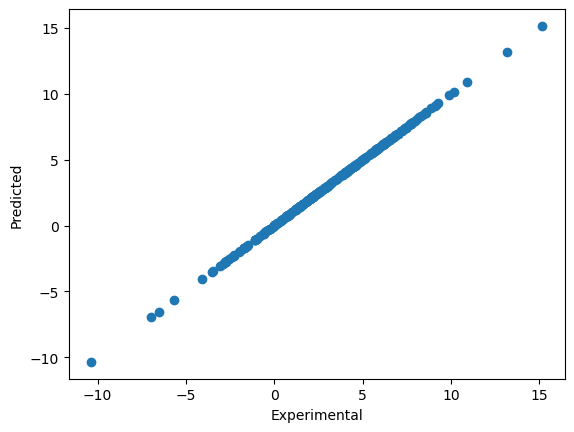


Running bootstrap resampling 500 samples for 95.0% CI

 |████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0% 

Completed bootstrap resampling


                  Completed all analysis
                 ------------------------

You can stand tall without standing on someone. You can be
a victor without having victims.  Harriet Woods



In [4]:
# Fit RS-HDMR surrogate model
model = rshdmr(
    dataframe,
    polys=[10, 5],
    n_iter=300,
    method='ard_cv',
    cv_method='bayesian',
    cv_tol=0.01,
    resampling=True,
    number_of_resamples=500,
)

sob, shap, total = model.run_all()

In [5]:
# Display the HDMR-based Shapley effects for reference
shap

,label,effect,scaled effect,lower,upper,std
0,X1,0.428125,0.428126,0.419034,0.430885,0.002863
1,X2,0.454775,0.454777,0.450255,0.468818,0.004733
2,X3,0.117097,0.117097,0.111584,0.119011,0.002001


---
### Example 1: MC Shapley with the Surrogate Model (Independent Inputs)

When no distribution or function is provided, `get_mc_shapley()` uses the trained surrogate model's `predict()` method and constructs a `GaussianCopulaUniform` distribution from the training data ranges. With no correlation matrix specified, this defaults to independent inputs.

In [6]:
# MC Shapley with surrogate model, independent inputs
# N=5000: sample size; method='exhaustive': enumerate all subsets; B=200: bootstrap replications
mc_indep = model.get_mc_shapley(
    N=5000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    random_state=42,
)
mc_indep

,variable,effect,shapley_value,total_variance,lower,upper
0,X1,0.443681,5.792161,13.054799,0.424064,0.464268
1,X2,0.463158,6.046433,13.054799,0.443938,0.482624
2,X3,0.093162,1.216205,13.054799,0.066347,0.115010


---
### Example 2: MC Shapley with the Surrogate Model (Correlated Inputs)

To account for correlation between inputs, provide a correlation matrix via the `corr` parameter. This constructs a `GaussianCopulaUniform` distribution where the underlying normal has the specified correlation structure. The surrogate model's predictions are evaluated on samples drawn from this correlated distribution.

In [7]:
# Define a correlation matrix: X1 and X3 are strongly correlated (0.8)
corr = np.array([
    [1.0, 0.0, 0.8],
    [0.0, 1.0, 0.0],
    [0.8, 0.0, 1.0],
])

# MC Shapley with correlated inputs via the surrogate model
mc_corr = model.get_mc_shapley(
    corr=corr,
    N=5000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    random_state=42,
)
mc_corr

,variable,effect,shapley_value,total_variance,lower,upper
0,X1,0.223880,2.440965,10.902983,0.207466,0.237821
1,X2,0.542643,5.916427,10.902983,0.523977,0.560735
2,X3,0.233477,2.545591,10.902983,0.213765,0.251663


##### Visual comparison: independent vs correlated

The bar chart below compares Shapley effects estimated under independent and correlated input assumptions. With strong positive correlation between $X_1$ and $X_3$, their individual contributions shift because they carry shared information.

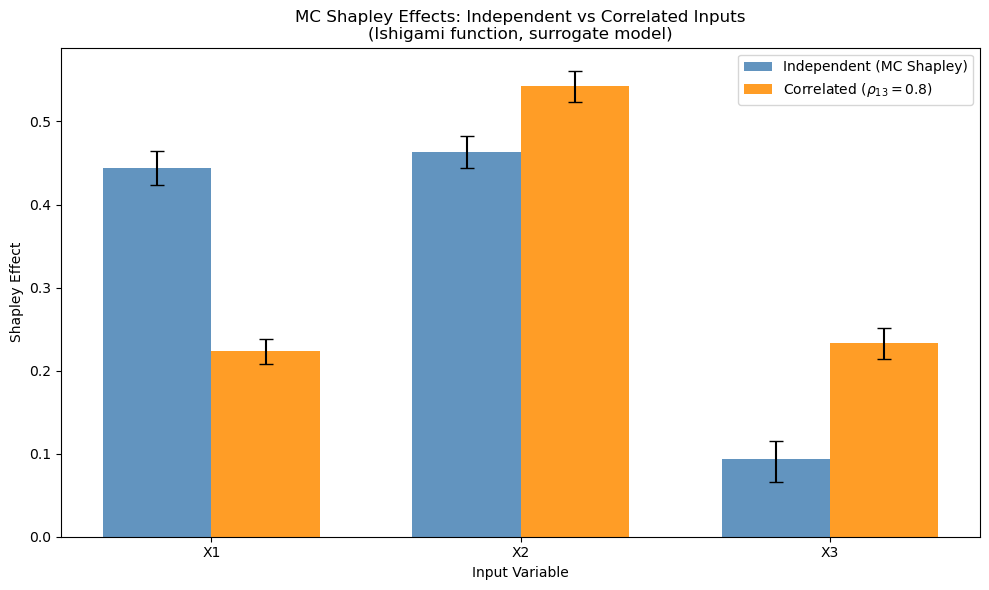

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
x = np.arange(d)

# Independent
ax.bar(
    x - bar_width / 2, mc_indep['effect'], bar_width,
    yerr=[mc_indep['effect'] - mc_indep['lower'],
          mc_indep['upper'] - mc_indep['effect']],
    capsize=5, label='Independent (MC Shapley)',
    color='steelblue', alpha=0.85,
)

# Correlated
ax.bar(
    x + bar_width / 2, mc_corr['effect'], bar_width,
    yerr=[mc_corr['effect'] - mc_corr['lower'],
          mc_corr['upper'] - mc_corr['effect']],
    capsize=5, label=r'Correlated ($\rho_{13}=0.8$)',
    color='darkorange', alpha=0.85,
)

ax.set_xlabel('Input Variable')
ax.set_ylabel('Shapley Effect')
ax.set_title('MC Shapley Effects: Independent vs Correlated Inputs\n(Ishigami function, surrogate model)')
ax.set_xticks(x)
ax.set_xticklabels(mc_indep['variable'])
ax.legend()
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

---
### Example 3: MC Shapley with a User-Defined Function

The method is not limited to the surrogate model. You can pass any callable `f(x)` that takes a 1D numpy array and returns a scalar, together with a custom distribution. This is useful for:
- Comparing analytical sensitivity indices
- Evaluating black-box models
- Testing the method on known benchmark functions

In [9]:
# Using the analytical Ishigami function directly with correlated uniforms
joint_corr = GaussianCopulaUniform(
    lows=[-np.pi] * d,
    highs=[np.pi] * d,
    corr=corr,
)

mc_user = model.get_mc_shapley(
    joint=joint_corr,
    f=ishigami_1d,           # User-defined function
    N=5000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    random_state=42,
)
mc_user

,variable,effect,shapley_value,total_variance,lower,upper
0,X1,0.232415,2.651994,11.410575,0.216431,0.246995
1,X2,0.533455,6.087025,11.410575,0.513984,0.552442
2,X3,0.234130,2.671555,11.410575,0.214024,0.253240


##### Compare surrogate-based vs analytical function (both correlated)

This verifies that the surrogate model faithfully reproduces the sensitivity structure of the original function, even under correlated inputs.

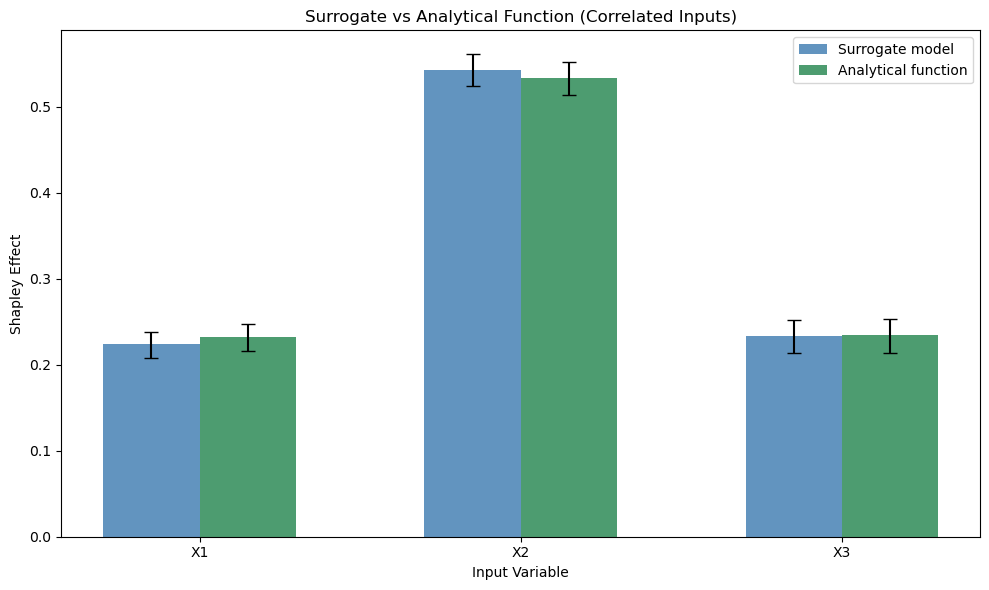

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.3
x = np.arange(d)

ax.bar(
    x - bar_width / 2, mc_corr['effect'], bar_width,
    yerr=[mc_corr['effect'] - mc_corr['lower'],
          mc_corr['upper'] - mc_corr['effect']],
    capsize=5, label='Surrogate model',
    color='steelblue', alpha=0.85,
)

ax.bar(
    x + bar_width / 2, mc_user['effect'], bar_width,
    yerr=[mc_user['effect'] - mc_user['lower'],
          mc_user['upper'] - mc_user['effect']],
    capsize=5, label='Analytical function',
    color='seagreen', alpha=0.85,
)

ax.set_xlabel('Input Variable')
ax.set_ylabel('Shapley Effect')
ax.set_title('Surrogate vs Analytical Function (Correlated Inputs)')
ax.set_xticks(x)
ax.set_xticklabels(mc_corr['variable'])
ax.legend()
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

---
### Example 4: Multivariate Normal Distribution

For models where inputs are naturally normally distributed, use `MultivariateNormal` instead. This is common in applications where inputs represent physical quantities with known mean and covariance structure.

In [11]:
# Define a test function appropriate for normally-distributed inputs
def quadratic_fn(x):
    """Quadratic function: x0 + 2*x1^2 + 0.5*x0*x2"""
    return x[0] + 2.0 * x[1]**2 + 0.5 * x[0] * x[2]


# Multivariate normal with correlation between X1 and X2
mean = [0.0, 0.0, 0.0]
cov = np.array([
    [1.0, 0.7, 0.0],
    [0.7, 1.0, 0.0],
    [0.0, 0.0, 1.0],
])

joint_normal = MultivariateNormal(mean, cov)

mc_normal = model.get_mc_shapley(
    joint=joint_normal,
    f=quadratic_fn,
    N=5000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    random_state=42,
)
mc_normal

,variable,effect,shapley_value,total_variance,lower,upper
0,X1,0.153445,1.273282,8.297979,0.096077,0.209852
1,X2,0.899872,7.467123,8.297979,0.827443,0.971203
2,X3,-0.053317,-0.442426,8.297979,-0.122636,0.000956


---
### Using the Permutation Method

For higher-dimensional problems where exhaustive enumeration ($2^d - 1$ subsets) becomes impractical, the permutation method offers a scalable alternative. It uses random permutations and lazy caching to approximate Shapley effects without enumerating all subsets.

In [12]:
# Permutation method: uses random permutations instead of exhaustive enumeration
mc_perm = model.get_mc_shapley(
    N=5000,
    method='permutation',
    n_perm=2000,           # Number of random permutations
    B=200,
    alpha=0.05,
    random_state=42,
)

print("Permutation method results:")
mc_perm

Permutation method results:


,variable,effect,shapley_value,total_variance,lower,upper
0,X1,0.421635,5.527148,13.108835,0.405265,0.442318
1,X2,0.457406,5.996059,13.108835,0.438908,0.476702
2,X3,0.120959,1.585627,13.108835,0.096346,0.139221


In [13]:
# Compare exhaustive vs permutation
comparison = pd.DataFrame({
    'Variable': mc_indep['variable'],
    'Exhaustive': mc_indep['effect'].values,
    'Permutation': mc_perm['effect'].values,
})
comparison['Difference'] = np.abs(
    comparison['Exhaustive'] - comparison['Permutation']
)
comparison

,Variable,Exhaustive,Permutation,Difference
0,X1,0.443681,0.421635,0.022045
1,X2,0.463158,0.457406,0.005752
2,X3,0.093162,0.120959,0.027797


In [14]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Wed, 29 Apr 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.8.0

matplotlib: 3.10.8
numpy     : 2.4.4
pandas    : 2.3.3
shapleyx  : 0.2

Watermark: 2.6.0

